In [ ]:
# When running in Google Colab, uncomment the next line to download the spectral library
# !wget -O generate_synthtetic_nwb_data.py "https://uni-bonn.sciebo.de/s/xQw582r7KHrTPSj/download"

[Neurodata Without Borders (NWB)](https://www.nwb.org/) is a community standard for sharing neurophysiology data. An NWB file is, on disk, an [HDF5](https://www.hdfgroup.org/solutions/hdf5/) file with a hierarchy tailored for neuroscience data: raw recordings live under `/acquisition`, derived signals under ` processing`, subject and experiment metadata under `/general`, trial structure under `/intervals/trials`, and spike-sorted units under `/units`. Because NWB is *just HDF5 with a schema*, you can open it two ways:

- With **h5py**, to inspect groups, datasets, and attributes directly. This is useful when you want to see how the file is laid out or when you suspect a file is malformed.
- With **pynwb**, which reads the HDF5 file into typed Python objects (`NWBFile`, `ElectricalSeries`, `Units`, ...) that know about units, time bases, and electrode references. This is what you'll normally use for analysis.

In this session you'll do both on a small synthetic dataset.

## Setup

Import the libraries we'll need. `h5py` is the low-level HDF5 reader; `pynwb` is the NWB-aware library; `numpy`, `pandas`, and `matplotlib` are for working with the data once we've read it.


In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from uuid import uuid4

from pynwb import NWBHDF5IO

### The synthetic NWB file
In the exercises in this notebook you will read from a small synthetic file, `synthetic_session.nwb`. Run the cell below to generate the data and construct the file. It imitates data from a single mouse subject with data from an 8-channel probe split across V1 and hippocampus. You can also open up the terminal and run the script with the same command there (without the exclamation point) if you have activated the right environment.

In [3]:
!python generate_synthetic_nwb_data.py

Wrote synthetic_session.nwb


## Exploring NWB Structure with h5py

### Background

An NWB file is a single HDF5 file with. HDF5 organises data hierarchically: **groups** are like folders, **datasets** are like files holding numeric or string arrays, and both groups and datasets can carry **attributes** — short key/value pairs that store metadata (units, descriptions, neurodata types). When you open an NWB file with `h5py`, you see this raw layout, not the NWB-typed objects. Common top-level groups are:

- `/acquisition` — raw recorded signals (e.g. extracellular voltage)
- `/processing` — derived data organised into modules (e.g. LFP, behaviour)
- `/general` — subject, devices, electrode metadata
- `/intervals/trials` — trial table
- `/units` — sorted-unit spike times

Opening an NWB file with `h5py` is a quick way to confirm what's inside.

### Exercises

| Code | Description |
| --- | --- |
| `with NWBHDF5IO('synthetic_session.nwb', 'r') as io:`<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`# read content in f` | Open an NWB file for reading *with* a context manager |
| `io = NWBHDF5IO('synthetic_session.nwb', 'r')` | Opens an `nwb` file object for reading *without* a context manager |
| `io.close()` | Closes the `nwb` file after reading *without* a context manager. |
| `list(f.keys())` | List the top-level groups |
| `list(f['acquisition'].keys())` | List the entries in the `acquisition` group |
| `dset = f['acquisition/ElectricalSeries/data']` | Read a dataset and assign it to a variable named `dset` |
| `f['acquisition/ElectricalSeries/data'].shape` | Read a dataset's shape |
| `f['acquisition/ElectricalSeries/data'].dtype` | Read a dataset's dtype |
| `dict(f['acquisition/ElectricalSeries/data'].attrs)` | Read attributes of a dataset |
| `f.visit(lambda name: print(name))` | Walk every group and dataset recursively |
| `f['general/subject/species'][()]` | Read a scalar/string dataset (returns bytes for strings) |
| `f['session_description'][()].decode()` | Decode a string dataset to `str` |

**Example**: open the file and print a list of the top-level groups.


In [4]:
with h5py.File("synthetic_session.nwb", "r") as f:
    print(list(f.keys()))

['acquisition', 'analysis', 'file_create_date', 'general', 'identifier', 'intervals', 'processing', 'session_description', 'session_start_time', 'specifications', 'stimulus', 'timestamps_reference_time', 'units']


Alternative solution:

In [5]:
f = h5py.File("synthetic_session.nwb", "r")
print(list(f.keys()))
f.close()

['acquisition', 'analysis', 'file_create_date', 'general', 'identifier', 'intervals', 'processing', 'session_description', 'session_start_time', 'specifications', 'stimulus', 'timestamps_reference_time', 'units']


**Exercise**: print the list of entries inside the `acquisition` group.


**Exercise**: print the list of entries inside the `general` group.


**Exercise**: read and print the shape and dtype of the raw signal dataset at `acquisition/ElectricalSeries/data`.


**Exercise**: read the attributes attached to the same dataset. Which attribute tells you the physical unit of the recorded values?


**Exercise**: walk the entire file with `visit` and print every group and dataset path. This gives you a one-shot map of what's stored.

**Exercise**: read the subject's species from `general/subject/species`, assign it to a variable named `species`, and print it.

Below is a simplified file tree to illustrate the structure of the different contents of an NWB file. It can be handy to look back on if you are wondering about the relationship between different parts of the NWB file throughout the next sections.

```
NWBFile  ──────────────────── the whole session
│
├── acquisition ───────────── raw signals, by name
│     └── ElectricalSeries        ← TimeSeries (data + time base + unit)
│
├── processing ────────────── ProcessingModules (derived data)
│     └── "ecephys" ── ProcessingModule
│            └── LFP                  ──────────── a container / data interface
│                 └── ElectricalSeries "lfp"
|     └── "behavior" ── ProcessingModule
│            └── BehavioralTimeSeries ──────────── a container / data interface
│                 └── TimeSeries "running_speed"
│
├── intervals/trials ──────── DynamicTable  (one row per trial)
├── units ──────────────────  DynamicTable  (one row per neuron)
└── general/ ───────────────  metadata
      ├── subject                  ← Subject
      ├── devices/ …
      └── extracellular_ephys/electrodes ← DynamicTable (one row per electrode)
```

## Reading Data with pynwb

### Background

`h5py` is great for inspection, but for analysis of NWB-files you usually want *typed objects* (objects with information about what the data is). For example, instead of just a raw array with no information about sampling rates and what kind of data it is, you get an `ElectricalSeries` object that, together with the data array, contains a table of electrodes and metadata you can access by attribute.

`pynwb.NWBHDF5IO` opens an NWB file and `io.read()` reads it and returns an `NWBFile` object, which is a a typed view of the same HDF5 data you just explored.

Important: keep the file open while you access lazily-loaded data. Once the `NWBHDF5IO` `with`-block exits, slicing `.data[...]` may fail. You can either read inside the `with` block to automatically close the file after you have read what you wanted to read, or you can explictly call `io.close()` to close it.

### Exercises

| Code | Description |
| :-- | :-- |
| `with NWBHDF5IO('synthetic_session.nwb', 'r') as io:`<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`# read content in f` | Open an NWB file for reading *with* a context manager |
| `io = NWBHDF5IO('synthetic_session.nwb', 'r')` | Opens an `nwb` file object for reading *without* a context manager |
| `io.close()` | Closes the `nwb` file after reading *without* a context manager. |
| `nwb = io.read()` | Read into an `NWBFile` object |
| `nwb.session_description` | Read the session description string |
| `nwb.subject` | Get the subject object |
| `es = nwb.acquisition['ElectricalSeries']` | Get an acquisition time series by name and assign it to a variable. |
| `es.rate`, `es.starting_time` | Sampling rate and starting time of the series |
| `es.unit` | Physical unit of the data |
| `es.data[:10, 0]` | Access the first 10 samples of the first channel in the data. |
| `edf = nwb.electrodes.to_dataframe()` | Get electrode table as pandas DataFrame and assign it to variable `edf` |
| `edf.head()` | Get the first 5 rows of the pandas DataFrame |
| `edf["location"].value_counts()` | Count rows per category in a column |


**Example**: open the file with pynwb, read it into an `NWBFile`, and look at the `ElectricalSeries` in `acquisition` by printing it.

In [6]:
with NWBHDF5IO("synthetic_session.nwb", "r") as io:
    nwb = io.read()
    print(nwb.acquisition["ElectricalSeries"])

ElectricalSeries pynwb.ecephys.ElectricalSeries at 0x137049392789360
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (5000, 8), type "<f4">
  description: no description
  electrodes: electrodes <class 'hdmf.common.table.DynamicTableRegion'>
  offset: 0.0
  rate: 1000.0
  resolution: -1.0
  starting_time: 0.0
  starting_time_unit: seconds
  unit: volts



Alternative solution:

In [7]:
io = NWBHDF5IO("synthetic_session.nwb", "r")
nwb = io.read()
print(nwb.acquisition["ElectricalSeries"])
io.close()

ElectricalSeries pynwb.ecephys.ElectricalSeries at 0x137050640765712
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (5000, 8), type "<f4">
  description: no description
  electrodes: electrodes <class 'hdmf.common.table.DynamicTableRegion'>
  offset: 0.0
  rate: 1000.0
  resolution: -1.0
  starting_time: 0.0
  starting_time_unit: seconds
  unit: volts



**Exercise**: open the file with pynwb, read it into an `NWBFile`, and print `nwb.session_description`.


**Exercise**: open the file and print `nwb.subject`. Which species was recorded?


**Exercise**: assign the raw signal in `acquisition/ElectricalSeries` to a variable `es`. Print the sampling rate, starting time, and unit of the raw signal in `es`.


**Exercise**: Print the shape and data type of the raw signal in `acquisition/ElectricalSeries`. Note that for shape and dtype you need to access the data attribute of the ElectricalSeries object, i.e. `es.data.shape` and `es.data.dtype`.

**Exercise**: get the first 200 samples of channel 0 of the raw signal in `acquisition/ElectricalSeries` and assign to a variable named `y`. **Hint**: `es.data` to get the data. Then, run the second cell below to plot the signal.


In [ ]:
fig, ax = plt.subplots()
ax.plot(y)
ax.set_ylabel(f"voltage")
ax.set_title("Channel 0, first 200 samples")
plt.show()

**Exercise**: convert the electrode table to a pandas DataFrame, assign it to a variable named `edf`, and display the first few rows.


**Exercise**: from the same electrode DataFrame, count how many electrodes are in `V1` and how many are in `HPC`. **Hint**: See `value_counts()` in code reference table.


## DynamicTable - for Tabular Data like Trial Metadata and Unit Spike Events

### Background

A `DynamicTable` is a flexible row-and-column data structure used to store, among other things, trial data and  units data (activity of neurons). It has certain required columns (e.g. `start_time`, `stop_time` for trials; `spike_times` for units) as well as optional user-defined columns. The easiest way to work with `DynamicTables` is to call `.to_dataframe()` and treat it like any other pandas DataFrame.

In our synthetic file:
- The table `nwb.trials` has 10 trials, each with a `start_time`, `stop_time`, and a `stim_type` of either `'A'` or `'B'`.
- The table `nwb.units` has 3 sorted units, each with an array of spike times in seconds.

### Exercises

| Code | Description |
| --- | --- |
| `with h5py.File('synthetic_session.nwb', 'r') as f:`<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`# read content in f` | Open an HDF5/NWB file for reading |
| `nwb.trials.to_dataframe()` | Trial table as pandas DataFrame |
| `nwb.trials.colnames` | Column names of the trial table |
| `nwb.units.to_dataframe()` | Units table as pandas DataFrame |
| `nwb.units["spike_times"][i]` | Spike times of the i-th unit |
| `nwb.units["spike_times"][:]` | Spike times of all units (list of arrays) |
| `len(nwb.units["spike_times"][i])` | Number of spikes of the i-th unit |
| `len(nwb.units)` | Number of units |


**Example**: load the trial table as a pandas DataFrame, and display it.


In [9]:
with NWBHDF5IO("synthetic_session.nwb", "r") as io:
    nwb = io.read()
    trials_df = nwb.trials.to_dataframe()
trials_df

,start_time,stop_time,stim_type
id,,,
0,0.0,0.3,A
1,0.5,0.8,B
2,1.0,1.3,A
3,1.5,1.8,B
4,2.0,2.3,A
5,2.5,2.8,B
6,3.0,3.3,A
7,3.5,3.8,B
8,4.0,4.3,A


**Exercise**: print the trial table's column names.


**Exercise**: load the units table as a pandas DataFrame, and display it.


**Example**: get the spike times of unit 0 and print the first five timestamps.


In [10]:
with NWBHDF5IO("synthetic_session.nwb", "r") as io:
    nwb = io.read()
    st0 = nwb.units["spike_times"][0]
print(st0[:5])

[0.41953509 0.49117048 0.74386423 1.40682199 1.53924686]


**Exercise**: get the spike times of unit 2 and print the first five timestamps.


**Exercise**: get the spike times of all units and assign them to a variable named `sts`. Print the first five timestamps of unit 2 to check that you get the same result as in the previous exercise.


**Demo**: Run the cell below to read the spikes from all units and make a spike raster plot.

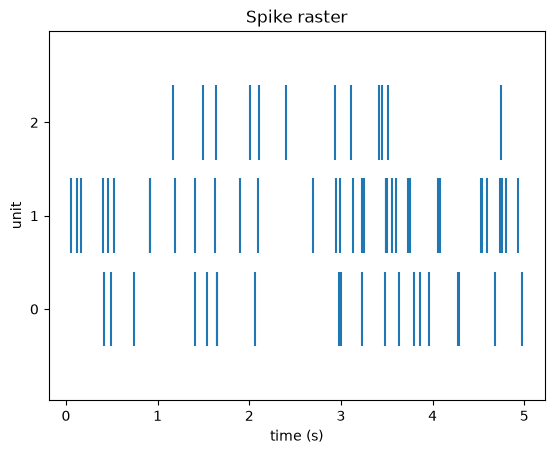

In [11]:
with NWBHDF5IO("synthetic_session.nwb", "r") as io:
    nwb = io.read()
    spikes = [nwb.units["spike_times"][i] for i in range(len(nwb.units))]

fig, ax = plt.subplots()
ax.eventplot(spikes, lineoffsets=np.arange(len(spikes)), linelengths=0.8)
ax.set_xlabel("time (s)")
ax.set_ylabel("unit")
ax.set_yticks(np.arange(len(spikes)))
ax.set_title("Spike raster")
plt.show()

## Processed Data: LFP and Behavioral Variables

### Background

Data processed from the raw signal, like filtered LFP, behavioural variables, and spike-sorting output, is stored in `nwb.processing`.

Processed data is grouped by topic into `ProcessingModule`s, one per kind of data (for example one for electrophysiology-derived signals, one for behaviour). Within a module, the data is put in typed containers (such as `LFP` or `BehavioralTimeSeries`) that wrap the time series. Reading processed data is therefore a matter of navigating from `nwb.processing` to the right module, then to the container, and finally to the series inside it.

In our synthetic file, there are two processing modules:

- `nwb.processing['ecephys']` contains an `LFP` container whose `electrical_series['lfp']` is the raw signal downsampled to 250 Hz.
- `nwb.processing['behavior']` contains a `BehavioralTimeSeries` container with two behavioural signals sampled at 50 Hz: `running_speed` (in cm/s) and `pupil_diameter` (in mm).

### Exercises

| Code | Description |
| :-- | :-- |
| `with h5py.File('synthetic_session.nwb', 'r') as f:`<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`# read content in f` | Open an HDF5/NWB file for reading |
| `list(nwb.processing.keys())` | List processing modules |
| `nwb.processing['ecephys'].data_interfaces` | Get items inside a module |
| `nwb.processing['ecephys']['LFP']` | Get the LFP container |
| `lfp.electrical_series['lfp']` | Get the LFP time series object `ElectricalSeries` |
| `es_lfp.starting_time + np.arange(n) / es_lfp.rate` | Build a time axis for the LFP samples |
| `data.mean(axis=0)` | Per-channel mean across time |
| `edf.groupby("location")["lfp_mean"].mean()` | Average a per-channel value by region |
| `nwb.processing['behavior']` | Get the behaviour module |
| `bts = nwb.processing['behavior']['BehavioralTimeSeries']` | Get the `BehavioralTimeSeries` container |
| `list(bts.time_series.keys())` | List the behavioural series in the container |
| `rs = bts['running_speed']` | Get a behavioural `TimeSeries` by name |
| `rs.data[:]`, `rs.rate`, `rs.unit` | Data array, sampling rate, and unit of a series |
| `rs.starting_time + np.arange(n) / rs.rate` | Build a time axis for a behavioural series |
| `np.corrcoef(a, b)[0, 1]` | Pearson correlation between two 1-D arrays |


**Example**: list the processing modules in the file.


In [12]:
with NWBHDF5IO("synthetic_session.nwb", "r") as io:
    nwb = io.read()
    print(list(nwb.processing.keys()))

['behavior', 'ecephys']


**Exercise**: list the data interfaces inside the `ecephys` module.


**Exercise**: get the LFP time series `ElectricalSeries` and print its sampling rate. How does it compare to the raw signal's 1000 Hz?


**Exercise**: plot LFP channel 0 over time.


Now that you have read the LFP from the `ecephys` module, turn to the behavioural variables stored in the `behavior` module.

**Example**: get the `behavior` processing module and list the data interfaces (containers) inside it.

In [13]:
with NWBHDF5IO("synthetic_session.nwb", "r") as io:
    nwb = io.read()
    behavior = nwb.processing["behavior"]
    print(list(behavior.data_interfaces.keys()))

['BehavioralTimeSeries']


**Exercise**: get the `BehavioralTimeSeries` container from the `behavior` module and list the behavioural series inside it. **Hint**: a `BehavioralTimeSeries` exposes its series through `.time_series`, just like the `LFP` container exposes `.electrical_series`.

**Exercise**: get the `running_speed` series from the container and print its unit.

**Exercise**: plot running speed over time. Build the time axis from `starting_time` and `rate` the same way you did for the LFP.

**Exercise**: plot the `pupil_diameter` over time.

**(Bonus) Exercise**: compute the mean LFP amplitude per electrode and group the result by brain region (`V1` vs `HPC`) using the electrode table.


location
HPC   -5.126826e-07
V1    -1.076278e-06
Name: lfp_mean, dtype: float32
